# Introduction to Data Science – Homework 6
*COMP 5360 / MATH 4100, University of Utah, http://datasciencecourse.net/*

Due: Friday, Feburary 28 2025, 11:59pm.

In Part 1 of this homework you will scrape github repositories and organize the information in a Pandas dataframe. In Part 2, you will use linear regression to gain meaningful insights. 

## Your Data
First Name: Ibrahim
<br>
Last Name: Ergin
<br>
E-mail: u1564808@utah.edu
<br>
UID: u1564808
<br>

In [134]:
# imports and setup 
from bs4 import BeautifulSoup

import pandas as pd
import scipy as sc
import numpy as np

import statsmodels.formula.api as sm

import matplotlib.pyplot as plt 
plt.style.use('ggplot')
%matplotlib inline  
plt.rcParams['figure.figsize'] = (10, 6) 
# where the data is stored
DATA_PATH = "snapshots"

### 1. Scrape Github Repository List using BeautifulSoup
In this part you will explore Github repositories, specifically the 100 most-starred repositories. You are going to scrape data from a snapshot of [this repository list](https://github.com/search?o=desc&q=stars%3A%3E1&s=stars&type=Repositories).

### 1.1. Check whether you are permitted to scrape the data
Before you start to scrape any website you should go through the terms of service and policy documents of the website. Almost all websites post conditions to use their data. Check the terms of [https://github.com/](https://github.com/) (see the tiny "terms" link at the bottom of the page) to see whether the site permits you to scrape their data or not. Are you sure you are allowed to scrape?

**Your solution:**

According to GitHub's [Acceptable Use Policies](https://help.github.com/en/github/site-policy/github-acceptable-use-policies#5-scraping-and-api-usage-restrictions), scraping is permitted under the following conditions:

- Researchers may scrape public, non-personal information from GitHub for 'research purposes', only if any publications resulting from that research are open access.
- Archivists may scrape GitHub for public data for archival purposes.
- You may not scrape GitHub for spamming purposes (e.g. to sell user information).

Since we are scraping public repository metadata for an 'educational/research' assignment and not publishing or selling any personal data, this use is permissible. GitHub's 'robots.txt' also does not explicitly disallow scraping the search result pages we are targeting. We are also working from local HTML snapshots rather than hitting GitHub's servers repeatedly, which further respects the spirit of these policies.

---------------------------

Reference solution: The [terms of service](https://help.github.com/articles/github-terms-of-service/) do not mention scraping, but the [help pages on the site policy](https://help.github.com/en/github/site-policy/github-acceptable-use-policies#5-scraping-and-api-usage-restrictionsyou) allows scraping. You can scrape Github under the following conditions:

- Researchers may scrape public, non-personal information from GitHub for research purposes, only if any publications resulting from that research are open access.
- Archivists may scrape GitHub for public data for archival purposes.
- You may not scrape GitHub for spamming purposes, including for the purposes of selling GitHub users' personal information, such as to recruiters, headhunters, and job boards.

The [robots.txt](https://github.com/robots.txt) is a little less explicit about what is allowed and what not, but overall, since we are scraping Github pages for education/research purposes and not publishing the results, it is reasonable to assume that this is ok to do.

### Task 1.2 Load the Data

To avoid any problems with GitHub blocking us from downloading the data many times, we have downloaded and saved a snapshot of the html files for you in the [snapshots](snapshots) folder. Note that the snapshots folder is not completely consistent with what you see on the web – we've made a few patches to the data that makes your task here easier and this data represents a snapshot in time. You will be treating the data folder as your website to be scraped. The path to data folder is stored in `DATA_PATH` variable.

In the data folder you will find first 10 pages of highly starred repositories saved as `search_page_1.html`,`search_page_2.html`,`search_page_3.html` ... `search_page_10.html`

Check out page 5 if you want to see what happens if you scrape too quickly 😉. **Tip**: you should skip page 5.

Now read these html files in python and create a soup object. This is a two step process:
 * Read the text in the html files
 * Create the soup from the files that you've read. 

In [135]:
pages = []
for i in range(1, 11):
    if i == 5:  # Skip page 5 
        continue
    file_path = f"{DATA_PATH}/search_page_{i}.html"
    with open(file_path, 'r', encoding='utf-8') as f:
        pages.append(f.read())

print(f"{len(pages)} pages loaded.")

9 pages loaded.


In [136]:
# Creating the soup
soups = [BeautifulSoup(page, 'html.parser') for page in pages]
print(f"{len(soups)} soups created.")

9 soups created.


### Extracting Data

Extract the following data for each repository, and create a Pandas Dataframe with a row for each repository and a column for each of these datums. 

+ The name of the repository
+ The primary language (there are multiple or none, if multiple, use the first one, if none, use "none")
+ The number of watching
+ The number of stars
+ The number of forks
+ The number of issues
+ Number of commits
+ Number of pull requests, and

Here's an example for one repository, `freeCodeCamp/freeCodeCamp,` in our dataset: 
```python
{'name': 'freeCodeCamp',
'language': 'TypeScript',
'watching': '8500',
'stars': '410251',
'forks': '39007',
'issues': 168,
'commits': 37591,
'pull_requests':66
}
```
### Task 1.3 Extract repository URLs

If you look at the results of the 100 most-starred repositories [(this list)](https://github.com/search?o=desc&q=stars%3A%3E1&s=stars&type=Repositories), you will notice that all the information we want to extract for each repository is not in that list. This information is in the repository’s individual web page, for example [996icu](https://github.com/996icu/996.ICU). 

Therefore, you will first have to extract links of each repository from the soup you scraped earlier. When you extract the link for the repository, it will be a path to the stored HTML page for the repository. You will use this path to read the file and extract the above information.

Refer to the scraping lecture for details on how to do this. We recommend you use the web inspector to identify the relevant structures.

Example of a link that you need to extract - `996icu/996.ICU.html`. This means in the next task you need to access local folder `snapshots/996icu/996.ICU.html`. Similarly, for `521xueweihan/HelloGitHub.html` you should access `snapshots/521xueweihan/HelloGitHub.html` 

You may need to do string operations to get the desired format for the link. For example, if you get `raw_link = https://github.com/996icu/996.ICU`, you can do
`link = raw_link.replace("https://github.com/", "") + ".html"` so you get `996icu/996.ICU.html`.

Please title your output 'repo_list', and print this list once you have created it.

In [137]:
## Your code goes here

repo_list = []
    
for soup in soups:
    #<a class="prc-Link-Link-85e08" href="https://github.com/freeCodeCamp/freeCodeCamp">
    #   <span class="Text__StyledText-sc-17v1xeu-0 fsOMbO search-match">freeCodeCamp/freeCodeCamp</span>
    #</a>
    for a in soup.select("a[href^='https://github.com/']"):
        href = a.get('href', '')
        text = a.get_text(strip=True)
        if text.count('/') == 1: # Format as owner/repo
            link = href.replace("https://github.com/", "") + ".html"
            repo_list.append(link)

repo_list = list(dict.fromkeys(repo_list))
print(f"{len(repo_list)} repositories found.")
print(repo_list)


90 repositories found.
['freeCodeCamp/freeCodeCamp.html', 'EbookFoundation/free-programming-books.html', 'sindresorhus/awesome.html', 'codecrafters-io/build-your-own-x.html', 'public-apis/public-apis.html', 'jwasham/coding-interview-university.html', 'kamranahmedse/developer-roadmap.html', 'donnemartin/system-design-primer.html', '996icu/996.ICU.html', 'vinta/awesome-python.html', 'facebook/react.html', 'practical-tutorials/project-based-learning.html', 'awesome-selfhosted/awesome-selfhosted.html', 'vuejs/vue.html', 'TheAlgorithms/Python.html', 'trekhleb/javascript-algorithms.html', 'tensorflow/tensorflow.html', 'torvalds/linux.html', 'getify/You-Dont-Know-JS.html', 'CyC2018/CS-Notes.html', 'ohmyzsh/ohmyzsh.html', 'ossu/computer-science.html', 'Significant-Gravitas/AutoGPT.html', 'twbs/bootstrap.html', 'flutter/flutter.html', 'microsoft/vscode.html', 'github/gitignore.html', 'jackfrued/Python-100-Days.html', 'trimstray/the-book-of-secret-knowledge.html', 'jlevy/the-art-of-command-line.

### Task 1.4 Extracting required information

Once you have extracted links for each repository, you can start parsing those HTML pages using BeautifulSoup and extract all the required information.

**Note**: There are few repositories which do not contain 'issues' field (such as 996icu/996.ICU.html). Therefore, write your code such that it handles this condition as well.

**Save the dataframe you created to a new file project_info.csv and include this in your submission.** This separate file will also be graded and is required to earn points.

You also need to make sure that you reformat all numerical columns to be integer data. You can do that either as you parse, or when you have a dataframe with strings.

Some repositories (~30) are missing in the collection, we have provided code to skip these cases, and similarly in the next frame to NOT include the None numbers in the storage.

**Tips**: the exact value of stars and forks can be found on top right corner, with mouse hover over the value. E.g., hover over 410k, shows 410,246. For *watching*, the data is abbreviated, You need to manually convert it. For example, 8.5k should be converted to 8500.

In [138]:
from pathlib import Path

def extract_repository_details(url):
    row = []
    
    file_path = Path("snapshots") / url
    if file_path.exists():
        with file_path.open('r', encoding="utf8") as f:
            file = f.read()
    else:
        parts = url.split('/')
        owner = parts[0]
        repo_file = parts[1]
        repo_name = repo_file.replace('.html', '')
        file_path = Path("snapshots") / f"{owner}_{repo_name}" / repo_file
        if not file_path.exists():
            print(f"Missing data for {file_path}, skipping.")
            return None
        with file_path.open('r', encoding="utf8") as f:
            file = f.read()

    ## Your code goes here
    soup = BeautifulSoup(file, 'html.parser')

    # Name
    repo_name = soup.find('strong', itemprop='name').get_text(strip=True)

    # Language
    lang_a = soup.select_one('a[href*="/search?l="]')
    if lang_a:
        language = lang_a.select_one('span.text-bold').get_text(strip=True)
    else:
        language = 'none'

    # Stars, Forks, Issues, Pull Requests
    stars = None
    forks = None
    issues = None
    pull_requests = None
    for span in soup.select('span.Counter'):
        parent = (span.find_parent('a') or span.find_parent('li') or span).get_text(strip=True)
        title = span.get('title', '')
        if title.replace(',', '').isdigit():
            val = int(title.replace(',', ''))
            if 'Star' in parent:
                stars = val
            elif 'Fork' in parent:
                forks = val
            elif 'Issues' in parent:
                issues = val
            elif 'Pull reques' in parent:
                pull_requests = val

    # Watching
    watch_a = soup.select_one('a[href$="/watchers"]:not([href^="https"])')
    if watch_a and watch_a.find('strong'):
        watch_text = watch_a.find('strong').get_text(strip=True)
        if 'k' in watch_text:
            watching = int(float(watch_text.replace('k', '')) * 1000)
        else:
            watching = int(watch_text)
    else:
        watching = None

    # Commits
    commits_a = soup.select_one('a[href*="/commits/"]')
    if commits_a and commits_a.select_one('span.fgColor-default'):
        commits_text = commits_a.select_one('span.fgColor-default').get_text(strip=True)
        commits_text = commits_text.replace('Commits', '')
        commits_text = commits_text.replace(',', '')
        commits_text = commits_text.strip()
        commits = int(commits_text)
    else:
        commits = None

    data = {"name": repo_name,
            "language": language,
            "watching": watching,
            "stars": stars,
            "forks": forks,
            "issues": issues,
            "commits": commits,
            "pull_requests": pull_requests
    }
    return data

In [139]:
## complete extract_repository_details() before running this snippet
repo_info_list = []
for repo in repo_list:
    item = extract_repository_details(repo)
    if item is not None:  
        repo_info_list.append(item)

project_info = pd.DataFrame(repo_info_list)

# Convert to integers (None/NaN values)
numeric_cols = ['watching', 'stars', 'forks', 'issues', 'commits', 'pull_requests']
for col in numeric_cols:
    project_info[col] = project_info[col].fillna(0).astype(int) # Converting None/NaN as 0 then to int

project_info.to_csv('project_info.csv', index=False)

Missing data for snapshots\vuejs_vue\vue.html, skipping.
Missing data for snapshots\tensorflow_tensorflow\tensorflow.html, skipping.
Missing data for snapshots\Significant-Gravitas_AutoGPT\AutoGPT.html, skipping.
Missing data for snapshots\twbs_bootstrap\bootstrap.html, skipping.
Missing data for snapshots\flutter_flutter\flutter.html, skipping.
Missing data for snapshots\microsoft_vscode\vscode.html, skipping.
Missing data for snapshots\github_gitignore\gitignore.html, skipping.
Missing data for snapshots\jackfrued_Python-100-Days\Python-100-Days.html, skipping.
Missing data for snapshots\trimstray_the-book-of-secret-knowledge\the-book-of-secret-knowledge.html, skipping.
Missing data for snapshots\jlevy_the-art-of-command-line\the-art-of-command-line.html, skipping.
Missing data for snapshots\Snailclimb_JavaGuide\JavaGuide.html, skipping.
Missing data for snapshots\AUTOMATIC1111_stable-diffusion-webui\stable-diffusion-webui.html, skipping.
Missing data for snapshots\airbnb_javascript\

### 2. Analyzing the repository data

In this part, you will analyze the data collected in Part 1 using regression tools. The goal is to identify properties that make a repository popular. 

First, load the `project_info.csv` file in again. **We need you to do this so that we can run your code below without having to run your scraping code, which can be slow.**

In [140]:
project_info = pd.read_csv('project_info.csv')
project_info.head()

,name,language,watching,stars,forks,issues,commits,pull_requests
0,freeCodeCamp,TypeScript,8500,410251,39007,168,37591,66
1,free-programming-books,HTML,9800,350789,62853,29,9499,55
2,awesome,none,7800,347926,28559,12,1154,40
3,build-your-own-x,Markdown,5600,337532,31226,190,571,162
4,material-ui,TypeScript,1300,94823,32495,1674,26364,161


### Task 2.1.1 Describe the data

+ Get an overview of the data using the describe function.
+ Compute the correlation matrix, visualize it with a labeled heat map.
+ Interpret what you see, and discuss why some variables may or may not be correlated with others.

You can re-use code from your previous homework here.

In [141]:
# your code goes here - describe
project_info.describe()

,watching,stars,forks,issues,commits,pull_requests
count,50.000000,50.000000,50.000000,50.000000,5.000000e+01,50.000000
mean,3292.060000,156327.100000,26478.400000,609.400000,4.001360e+04,233.300000
std,2597.574626,89631.821675,17990.614216,867.746954,1.879334e+05,484.107099
min,242.000000,80669.000000,4394.000000,0.000000,2.040000e+02,0.000000
25%,1300.000000,87882.000000,10301.000000,29.750000,1.128500e+03,37.000000
50%,2700.000000,109510.000000,23081.000000,133.500000,4.201000e+03,86.000000
75%,5525.000000,195646.750000,36002.750000,1099.750000,2.552600e+04,285.000000
max,9800.000000,410251.000000,77981.000000,3690.000000,1.336263e+06,3330.000000


In [142]:
# your code goes here - correlation matrix
numeric_cols = ['watching', 'stars', 'forks', 'issues', 'commits', 'pull_requests']
corr_matrix = project_info[numeric_cols].corr()
print(corr_matrix)

               watching     stars     forks    issues   commits  pull_requests
watching       1.000000  0.856652  0.634123 -0.414934  0.234133      -0.147657
stars          0.856652  1.000000  0.503909 -0.344872  0.031694      -0.151727
forks          0.634123  0.503909  1.000000 -0.122099  0.231079      -0.078197
issues        -0.414934 -0.344872 -0.122099  1.000000 -0.064845       0.069451
commits        0.234133  0.031694  0.231079 -0.064845  1.000000       0.110579
pull_requests -0.147657 -0.151727 -0.078197  0.069451  0.110579       1.000000


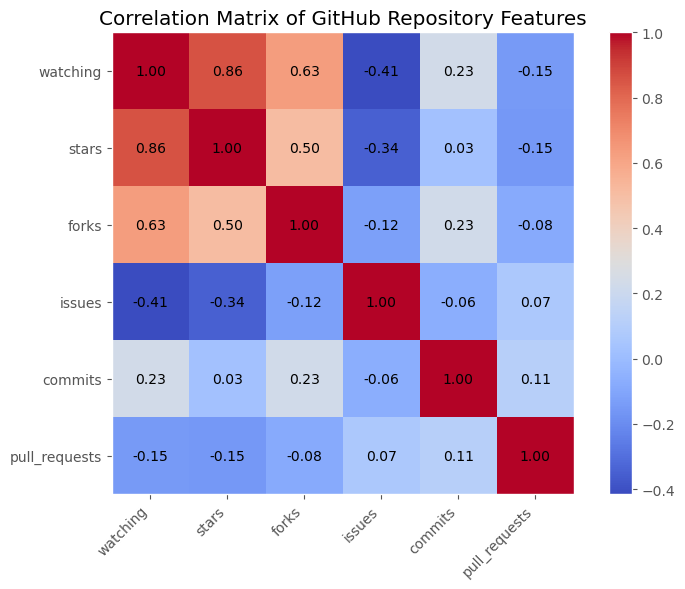

In [143]:
# your code goes here - heat map

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar(im)

cols = corr_matrix.columns
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)
ax.set_title('Correlation Matrix of GitHub Repository Features')
ax.grid(False)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center')

plt.tight_layout()
plt.show()

**Your Interpretation:** 

Stars and watching show the strongest correlation (0.86), as users who star a repo tend to also watch it. Forks moderately follow stars (0.50). Issues surprisingly correlates negatively with popularity metrics. Commits and pull requests are largely independent of popularity.


### Task 2.1.2 Scatterplot
+ Visualize the correlations by making a scatterplot matrix.
+ Interpret what you see. Compare this to the correlation matrix. Do either provide you with insight that the other does not?

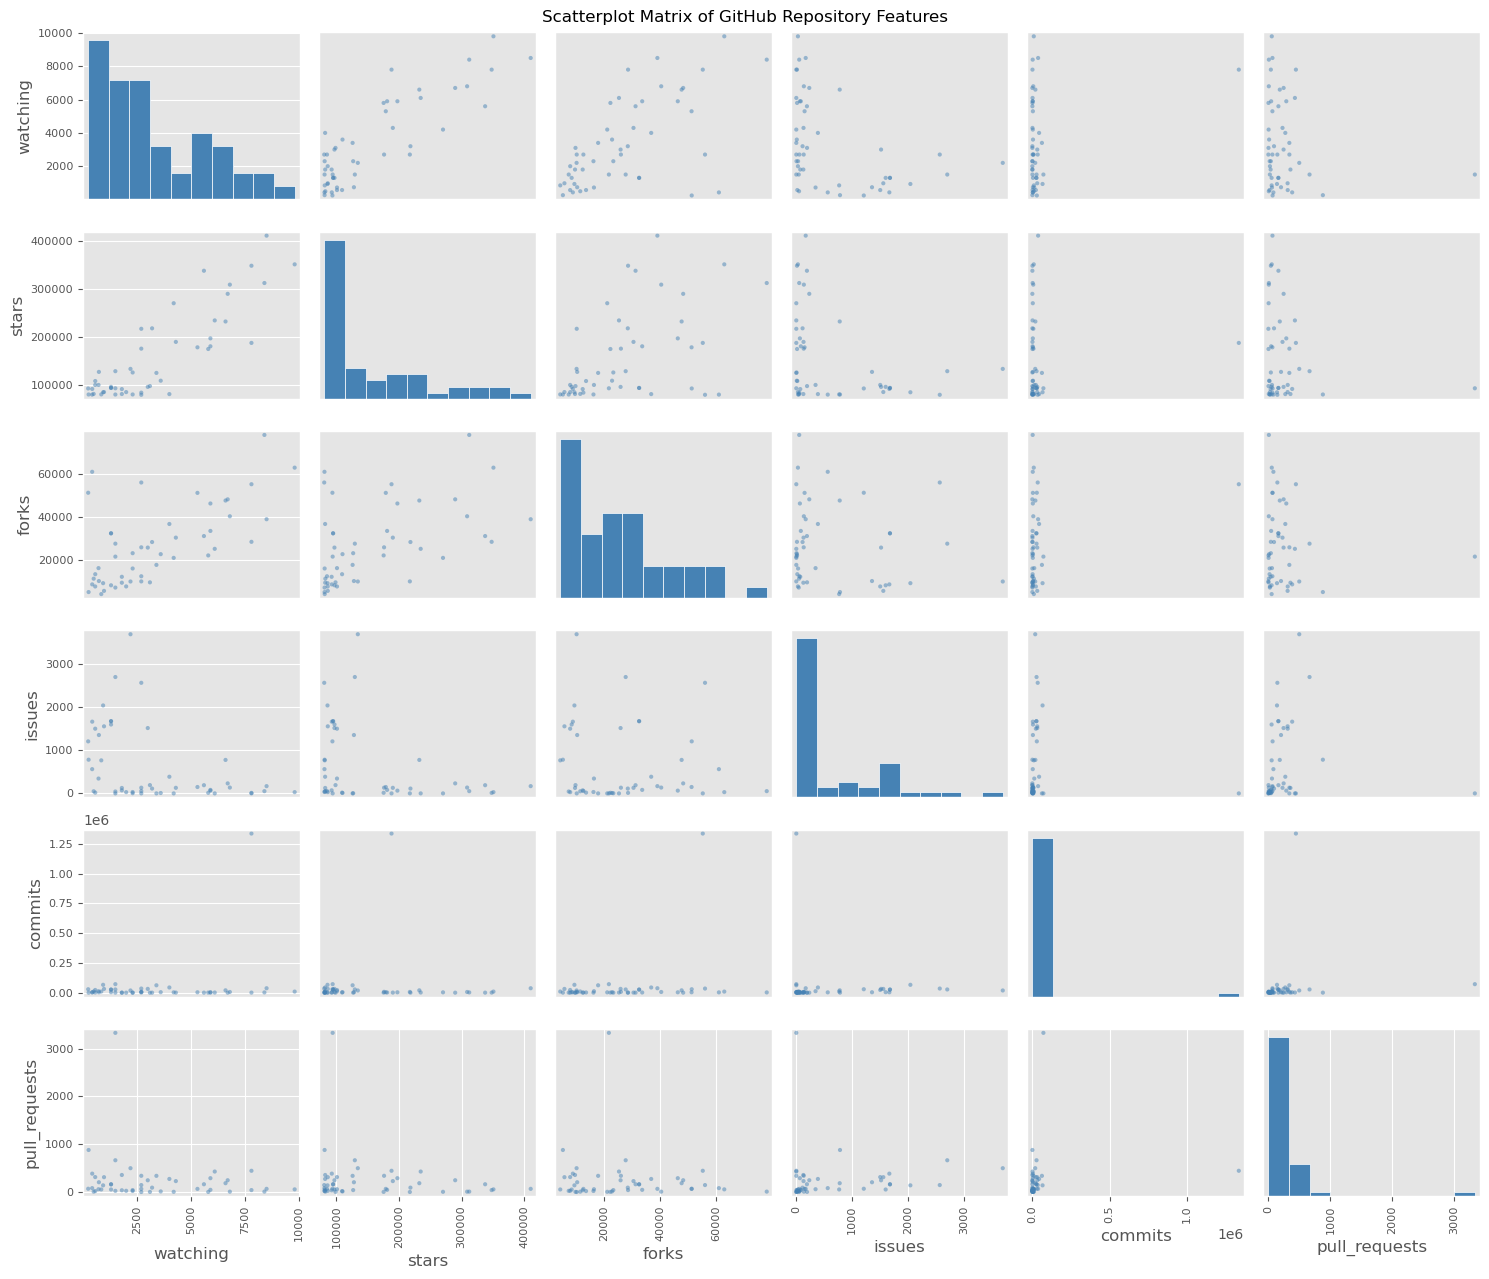

In [144]:
# your code goes here
pd.plotting.scatter_matrix(project_info[numeric_cols], 
                           figsize=(15, 13), 
                           diagonal='hist',
                           color='steelblue',
                           hist_kwds={'color': 'steelblue', 'edgecolor': 'white'})
plt.suptitle('Scatterplot Matrix of GitHub Repository Features')
plt.tight_layout()
plt.show()

**Your Interpretation:** 

The scatterplot matrix confirms the correlation findings. Stars and watching show the clearest linear relationship. All distributions are right-skewed with a few outliers. Commits and issues show no clear pattern against other variables, confirming their weak correlations.

### Task 2.2 Train/Test
+ Randomly partition the dataset into two groups, train and test, with an 80/20 split. Store these datasets, and use them for the remainder of the assignment. When you train a model, do so on the train set. When you evaluate a model, do so on the test set.




In [145]:
# your code goes here
from sklearn.model_selection import train_test_split

# Drop rows with NaN values in modeling columns
df = project_info.dropna(subset=numeric_cols)

# 80/20 split
train, test = train_test_split(df, test_size=0.2, random_state=42)

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

Train size: 40
Test size: 10


### 2.3.1 Linear regression

+ Use linear regression to try to predict the number of Stars based on Forks, Pull Requests, and Commits. Discuss the R-squared , F-statistic p-value, MSE, and coefficient  p-values seperately for the train set AND R-squared, MSE for the test set. 
+ Interpret your results. 


In [146]:
# your code goes here

from sklearn.metrics import mean_squared_error, r2_score

# Fit model
model = sm.ols('stars ~ forks + pull_requests + commits', data=train).fit()
print(model.summary())

# Train metrics
train_pred = model.predict(train)
print(f"Train MSE: {mean_squared_error(train['stars'], train_pred):.2f}")
print(f"Train R²: {r2_score(train['stars'], train_pred):.4f}")

# Test metrics
test_pred = model.predict(test)
print(f"Test MSE: {mean_squared_error(test['stars'], test_pred):.2f}")
print(f"Test R²: {r2_score(test['stars'], test_pred):.4f}")

                            OLS Regression Results                            
Dep. Variable:                  stars   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     6.418
Date:                Sat, 28 Feb 2026   Prob (F-statistic):            0.00135
Time:                        00:21:34   Log-Likelihood:                -506.60
No. Observations:                  40   AIC:                             1021.
Df Residuals:                      36   BIC:                             1028.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      9.391e+04   2.43e+04      3.865

**Your Interpretation:** 

The model explains 34.8% of variance in training data (R-squared=0.35) but performs poorly on test data (R-squared=-2.51), indicating overfitting. Forks is the only significant predictor (p=0.000) while pull_requests and commits are not significant. The small test set of 10 observations makes evaluation unreliable.

### 2.3.2 Linear Regression Exploration
+ Develop a model which is simpler AND a model which is more complex than in 2.3.1, with the aim of finding a model which performs better on the test set. Hint: refer to the correlation matrix.
+ Explain why your chosen model is better than the model in 2.3.1, explain your decision-making process for generating the models, and interpret your results. 

In [147]:
# your code goes here

# Simpler model — only forks
simple_model = sm.ols('stars ~ forks', data=train).fit()
simple_train_pred = simple_model.predict(train)
simple_test_pred = simple_model.predict(test)

print("--- Simple Model: stars ~ forks ---")
print(f"Train MSE: {mean_squared_error(train['stars'], simple_train_pred):.2f}")
print(f"Train R-squared: {r2_score(train['stars'], simple_train_pred):.4f}")
print(f"Test MSE: {mean_squared_error(test['stars'], simple_test_pred):.2f}")
print(f"Test R-squared: {r2_score(test['stars'], simple_test_pred):.4f}")

# Complex model — add watching and issues
complex_model = sm.ols('stars ~ forks + pull_requests + commits + watching + issues', data=train).fit()
complex_train_pred = complex_model.predict(train)
complex_test_pred = complex_model.predict(test)

print("\n--- Complex Model: stars ~ forks + pull_requests + commits + watching + issues ---")
print(f"Train MSE: {mean_squared_error(train['stars'], complex_train_pred):.2f}")
print(f"Train R-squared: {r2_score(train['stars'], complex_train_pred):.4f}")
print(f"Test MSE: {mean_squared_error(test['stars'], complex_test_pred):.2f}")
print(f"Test R-squared: {r2_score(test['stars'], complex_test_pred):.4f}")

--- Simple Model: stars ~ forks ---
Train MSE: 6184417244.49
Train R-squared: 0.3130
Test MSE: 5500363498.23
Test R-squared: -2.0393

--- Complex Model: stars ~ forks + pull_requests + commits + watching + issues ---
Train MSE: 1880379958.63
Train R-squared: 0.7911
Test MSE: 1975849999.97
Test R-squared: -0.0918


**Your Interpretation:** 

The simple model (only forks) generalizes slightly better than baseline despite lower training R-squared. The complex model fits training data well (R-squared=0.79) but still overfits. All models struggle due to the small dataset size.

### 2.4.1 Ridge Regression
Refer to section 6.2.1 of [ISL 2015](https://hastie.su.domains/ISLR2/ISLRv2_corrected_June_2023.pdf.download.html) for a description of ridge regression.
+ Implement ridge regression on both the variables for 2.3.1, and for your best solution from 2.3.2. 
+ Plot $\lambda$ (trained on the train set) against MSE (evaluated on the test set) in order to find an approximately optimal value. 
+ Explain your selection for $\lambda$.




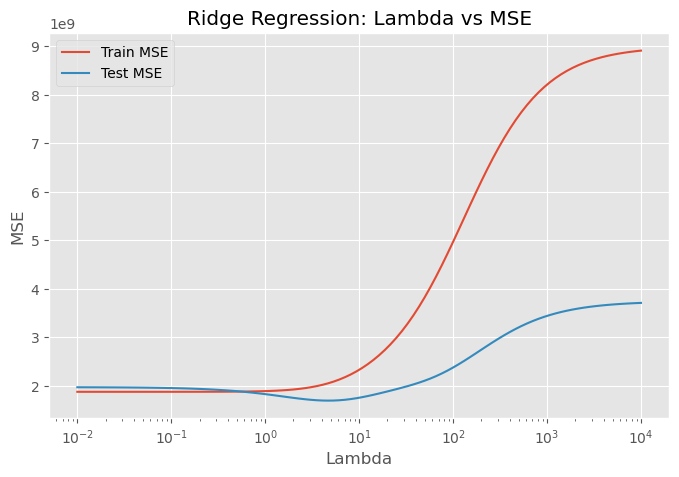

Best Lambda: 4.6416
Best Test MSE: 1698522501.16


In [148]:
# your code goes here

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

features = [col for col in numeric_cols if col != 'stars']
X_train = train[features]
y_train = train['stars']
X_test = test[features]
y_test = test['stars']

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Test different lambda values
lambdas = np.logspace(-2, 4, 100)
train_mses = []
test_mses = []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_scaled, y_train)
    train_mses.append(mean_squared_error(y_train, ridge.predict(X_train_scaled)))
    test_mses.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lambdas, train_mses, label='Train MSE')
plt.plot(lambdas, test_mses, label='Test MSE')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.title('Ridge Regression: Lambda vs MSE')
plt.legend()
plt.show()

# Best lambda
best_lam = lambdas[np.argmin(test_mses)]
print(f"Best Lambda: {best_lam:.4f}")
print(f"Best Test MSE: {min(test_mses):.2f}")

**Your Interpretation:** 

Ridge regression finds the best balance at lambda=4.64, achieving a test MSE of 1.70B which is lower than all OLS models. The small optimal lambda means only slight coefficient shrinkage was needed to improve generalization.

### 2.4.2 Lasso Regression
Refer to section 6.2.2 of [ISL 2015](https://hastie.su.domains/ISLR2/ISLRv2_corrected_June_2023.pdf.download.html) for a description of lasso regression.
+ Implement lasso regression on both the variables for 2.3.1, and for your best solution from 2.3.2. 
+ Plot $\lambda$ (trained on the train set) against MSE (evaluated on the test set) in order to find an approximately optimal value. 
+ Explain your selection for $\lambda$.




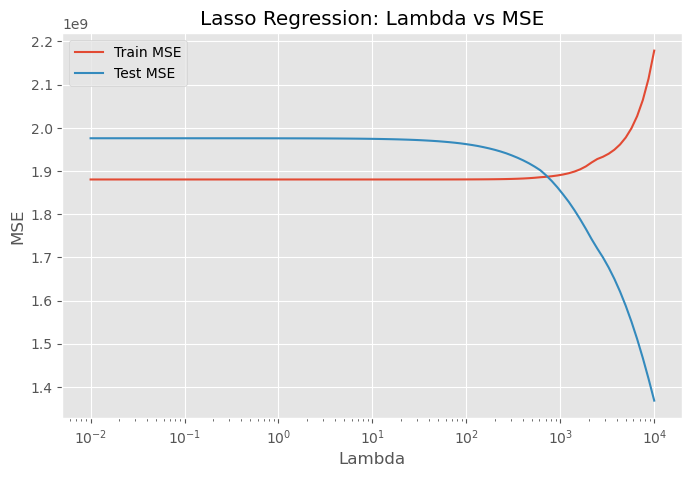

Best Lambda: 10000.0000
Best Test MSE: 1368242020.10


In [149]:
# your code goes here

from sklearn.linear_model import Lasso

train_mses_lasso = []
test_mses_lasso = []

for lam in lambdas:
    lasso = Lasso(alpha=lam, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    train_mses_lasso.append(mean_squared_error(y_train, lasso.predict(X_train_scaled)))
    test_mses_lasso.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lambdas, train_mses_lasso, label='Train MSE')
plt.plot(lambdas, test_mses_lasso, label='Test MSE')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.title('Lasso Regression: Lambda vs MSE')
plt.legend()
plt.show()

# Best lambda
best_lam_lasso = lambdas[np.argmin(test_mses_lasso)]
print(f"Best Lambda: {best_lam_lasso:.4f}")
print(f"Best Test MSE: {min(test_mses_lasso):.2f}")

**Your Interpretation:** 

Lasso performs best with a large lambda (10000), achieving the lowest test MSE of 1.37B across all models. The large lambda means Lasso zeroed out less important features, keeping only the most useful predictors.

### 2.5 Regression Methods Analysis
Compare the results of each regression method for this use case. Which one performed the best, and why?

In [150]:
print("Model Comparison:\n")
print(f"Simple OLS (forks only) - Test MSE: {mean_squared_error(y_test, simple_model.predict(test)):.2f}")
print(f"Baseline OLS (3 features) - Test MSE: {mean_squared_error(y_test, model.predict(test)):.2f}")
print(f"Complex OLS (5 features) - Test MSE: {mean_squared_error(y_test, complex_model.predict(test)):.2f}")
print(f"Ridge (lambda=4.64) - Test MSE: {min(test_mses):.2f}")
print(f"Lasso (lambda=10000) - Test MSE: {min(test_mses_lasso):.2f}")

Model Comparison:

Simple OLS (forks only) - Test MSE: 5500363498.23
Baseline OLS (3 features) - Test MSE: 6359004154.63
Complex OLS (5 features) - Test MSE: 1975849999.97
Ridge (lambda=4.64) - Test MSE: 1698522501.16
Lasso (lambda=10000) - Test MSE: 1368242020.10


**Your Interpretation:** 

Lasso regression performs best with the lowest test MSE of 1.37B, followed by Ridge (1.70B) and Complex OLS (1.98B). Both regularization methods outperform all OLS models, confirming that penalizing large coefficients helps generalization on this small dataset. Simple and Baseline OLS perform worst, showing that using forks alone or without regularization is insufficient for predicting stars.

### 2.6 Regression Methods Study
Based on your reading of the textbook and the prior exercises, explain the differences between linear, lasso, and ridge regression, and when you would want to use each.

**Your Interpretation:** 

**OLS (Ordinary Least Squares):** Fits the model by minimizing the sum of squared errors with no penalty. Works well with clean, low-dimensional data but struggles with multicollinearity and overfitting when features are correlated or the dataset is small.

**Lasso (L1):** Adds a penalty of lambda * sum(|coefficients|) to the loss function. Can shrink coefficients to exactly zero, effectively performing feature selection. Best when some features are irrelevant and a sparse model is preferred.

**Ridge (L2):** Adds a penalty of lambda * sum(coefficients**2) to the loss function. Shrinks all coefficients toward zero but never exactly zero. Best when all features contribute somewhat and multicollinearity is present.

In our case, Lasso performed best because it zeroed out less important features like commits and pull_requests, keeping only the strongest predictors of stars.